In [1]:
# importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# importing the dataset
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3,4]].values

In [3]:
# loading the dataset
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# loading the dataset
feature_columns = ['Annual Income (k$)', 'Spending Score (1-100)']
X = dataset[feature_columns].values

In [5]:
print(dataset.shape)

(200, 5)


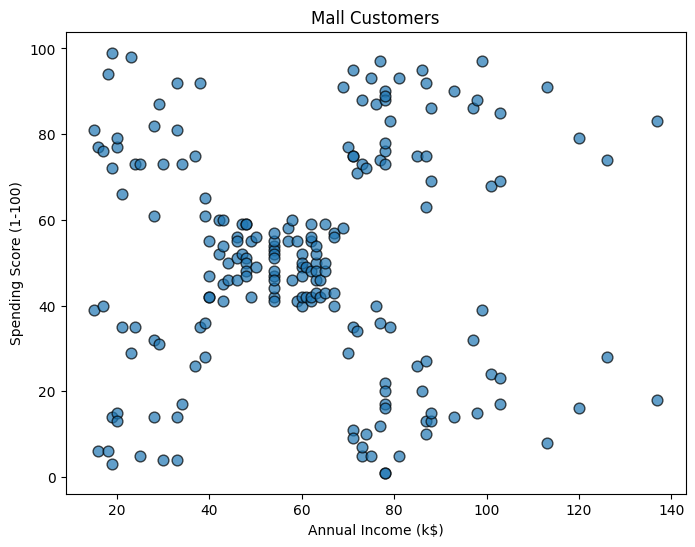

In [6]:
# visualizing the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=60, alpha=0.7, edgecolor='k')
plt.title('Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

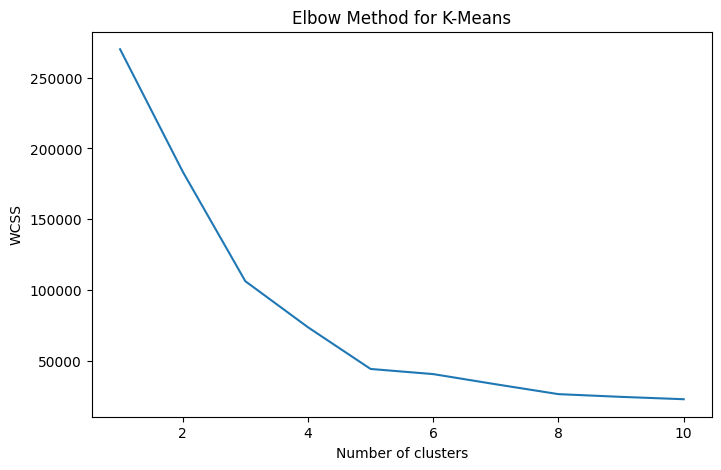

In [7]:
# using the elbow method to find the optimal number of clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, init='k-means++', random_state=42)
    model.fit(X)
    wcss.append(model.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

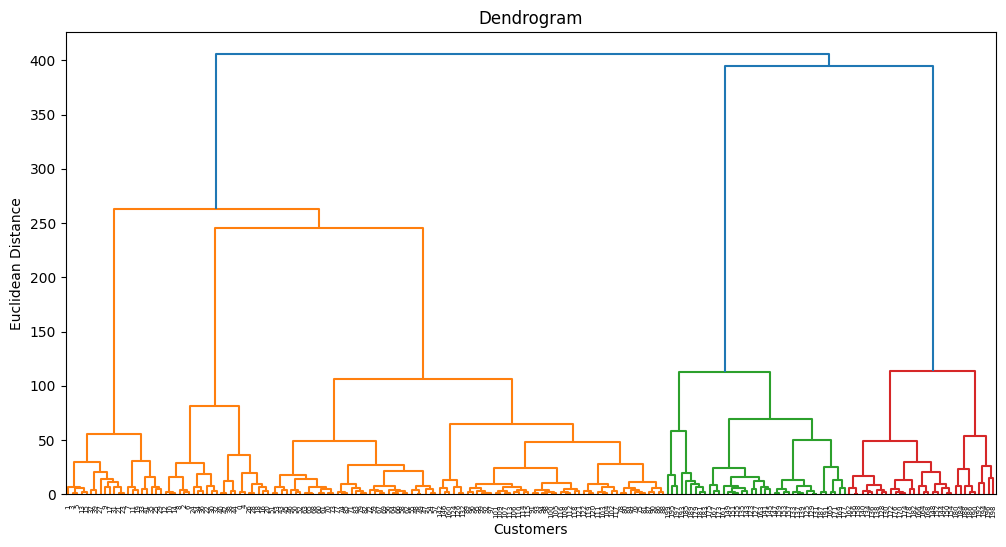

In [8]:
# using the dendrogram to find the optimal number of clusters
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

In [9]:
# training both models with the same number of clusters
from sklearn.cluster import AgglomerativeClustering
n_clusters = 5

kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
y_hierarchical = hierarchical.fit_predict(X)

In [10]:
# comparing the cluster assignments
comparison_df = dataset.copy()
comparison_df['KMeans Cluster'] = y_kmeans
comparison_df['Hierarchical Cluster'] = y_hierarchical
comparison_df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans Cluster,Hierarchical Cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,4
5,6,Female,22,17,76,2,3
6,7,Female,35,18,6,4,4
7,8,Female,23,18,94,2,3
8,9,Male,64,19,3,4,4
9,10,Female,30,19,72,2,3


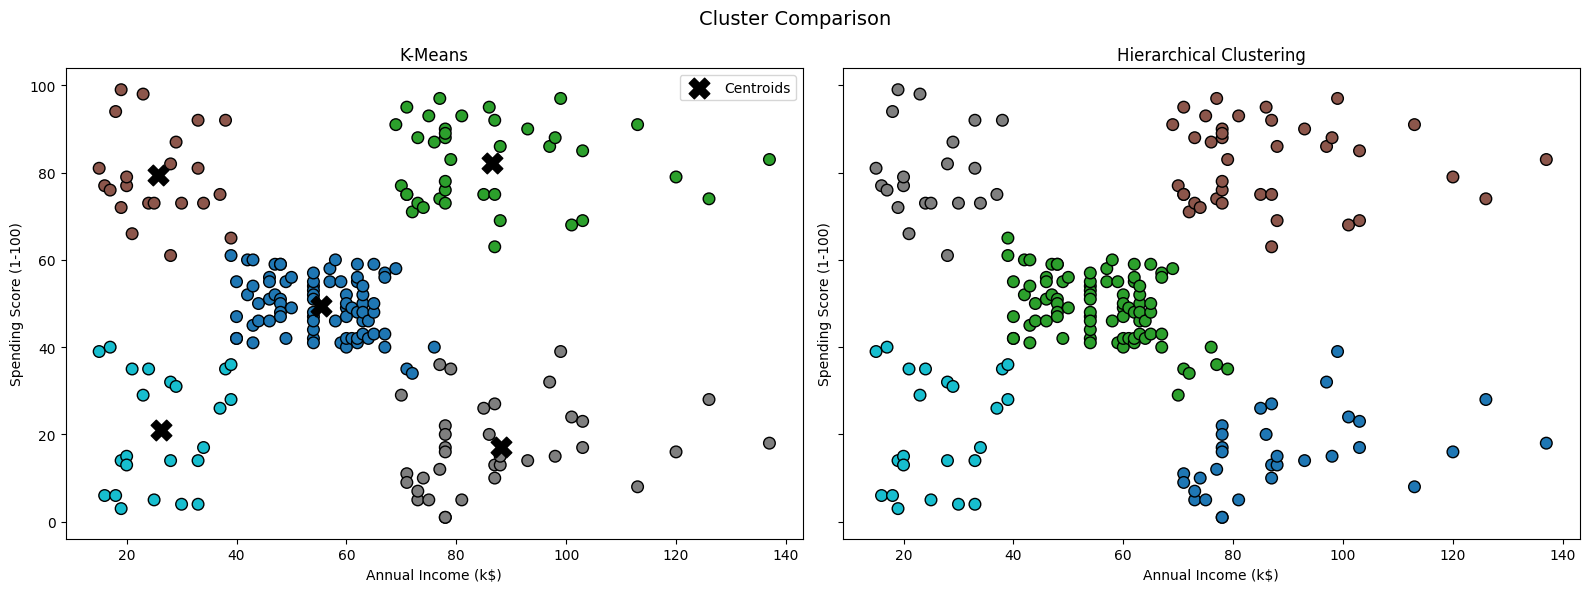

In [11]:
# visualizing the comparison between two clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

axes[0].scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='tab10', s=70, edgecolor='k')
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', s=220, marker='X', label='Centroids')
axes[0].set_title('K-Means')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], c=y_hierarchical, cmap='tab10', s=70, edgecolor='k')
axes[1].set_title('Hierarchical Clustering')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')

plt.suptitle('Cluster Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# evaluating clustering performance
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
metrics_df = pd.DataFrame([
    {
        'Model': 'K-Means',
        'Silhouette Score': silhouette_score(X, y_kmeans),
        'Calinski-Harabasz Score': calinski_harabasz_score(X, y_kmeans),
        'Davies-Bouldin Score': davies_bouldin_score(X, y_kmeans),
        'K-Means Inertia': kmeans.inertia_
    },
    {
        'Model': 'Hierarchical Clustering',
        'Silhouette Score': silhouette_score(X, y_hierarchical),
        'Calinski-Harabasz Score': calinski_harabasz_score(X, y_hierarchical),
        'Davies-Bouldin Score': davies_bouldin_score(X, y_hierarchical),
        'K-Means Inertia': np.nan
    }
])
metrics_df.style.format({
    'Silhouette Score': '{:.4f}',
    'Calinski-Harabasz Score': '{:.2f}',
    'Davies-Bouldin Score': '{:.4f}',
    'K-Means Inertia': '{:.2f}'
})

,Model,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,K-Means Inertia
0,K-Means,0.5539,247.36,0.5726,44448.46
1,Hierarchical Clustering,0.5530,243.07,0.5782,nan
